<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8016/blob/main/Session2_0_LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch.optim import Adam

# Perceptron

In [ ]:
def Perceptron():
    return nn.Sequential(
        nn.Flatten(),  # 2D -> 1D
        nn.Linear(32*32, 10) # classes: 0 - 9
    )

# MLP

In [ ]:
def MLPx(x=300):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(32*32, x),
        nn.Tanh(),
        nn.Linear(x, 10)
    )

In [ ]:
def MLPxy(x=300, y=100):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(32*32, x),
        nn.Tanh(),
        nn.Linear(x, y),
        nn.Tanh(),
        nn.Linear(y, 10),
    )

# LeNet

In [ ]:
def LeNet1():
    return nn.Sequential(
        #   in_chan,out_chan
        nn.Conv2d(1, 4, kernel_size=5, stride=1, padding=0),
        nn.Tanh(),
        nn.AvgPool2d(2,2),

        nn.Conv2d(4, 12, kernel_size=5, stride=1, padding=0),
        nn.Tanh(),
        nn.AvgPool2d(2,2),

        nn.Flatten(),
        nn.Linear(12*5*5, 10)
    )

In [ ]:
def LeNet4():
    return nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=5, stride=1),
        nn.Tanh(),
        nn.AvgPool2d(2,2),

        nn.Conv2d(64, 64, kernel_size=5, stride=1),
        nn.Tanh(),
        nn.AvgPool2d(2,2),

        nn.Flatten(),
        nn.Linear(64*5*5, 120),
        nn.Tanh(),
        nn.Linear(120, 10),
    )

In [ ]:
# 1D -> nn.Linear
# [n_batch,n_chan]

# 2D -> nn.Conv2D
# [n_batch,n_chan,H,W]

In [ ]:
# Input (RGB)         Varias capas            0    1 2 3
# [n_batch,3,H,W] --> ============ --> [n_batch,1024,1,1] -> Linear

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, n_chan=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(     1, n_chan, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(2,2),

            nn.Conv2d(n_chan, n_chan, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(2,2),

            nn.Conv2d(n_chan, n_chan, kernel_size=5, stride=1),
            nn.Tanh(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_chan*1*1, 84),
            nn.Tanh(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        # Extraemos caracteristicas visuales
        z = self.encoder(x)

        # Clasificamos
        return self.fc(z)

# Training

In [ ]:
def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

In [ ]:
def run(model, trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
        path="checkpoint", model_name="model"):

    # Crear carpeta si no existe
    os.makedirs(path, exist_ok=True)

    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=λ)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "eval_loss": [], "train_acc": [], "eval_acc": []}
    best_acc = 0.0
    ckpt_best = os.path.join(path, f"{model_name}_best.pt")
    ckpt_last = os.path.join(path, f"{model_name}_last.pt")

    for epoch in range(1, n_epoch+1):
        # Entrenamiento
        model.train()
        run_loss = run_acc = 0.0
        count = 0
        for x, y in trainLoader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            # Metrics
            run_loss += loss.item()
            run_acc += accuracy(logits, y)
            count += 1
        train_loss = run_loss/count
        train_acc  = run_acc/count

        # Evaluacion
        model.eval()
        run_loss = run_acc = 0.0
        count = 0
        with torch.no_grad():
            for x, y in evalLoader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                logits = model(x)
                loss = criterion(logits, y)

                run_loss += loss.item()
                run_acc  += accuracy(logits, y)
                count    += 1
        eval_loss = run_loss/count
        eval_acc  = run_acc /count

        # Guardar metricas
        history["train_loss"].append(train_loss)
        history[ "eval_loss"].append( eval_loss)
        history[ "train_acc"].append( train_acc)
        history[  "eval_acc"].append(  eval_acc)

        # Guardar checkpoints
        torch.save(model.state_dict(), ckpt_last)
        if eval_acc > best_acc:
            best_acc = eval_acc
            torch.save(model.state_dict(), ckpt_best)

        print(f"Epoch {epoch:02d} | "
              f"train {train_loss:.4f}/{100*train_acc:5.2f}% | "
              f"eval {eval_loss:.4f}/{100*eval_acc:5.2f}%")

    print(f"El mejor resultado: acc={best_acc*100:.2f}%")
    return {"model": model, "history": history, "name": model_name}

In [ ]:
def plot_history(hist, title="Modelo"):
    epochs = range(1, len(hist["train_loss"])+1)

    fig, ax1 = plt.subplots(figsize=(6,4))

    # Loss
    l1, = ax1.plot(epochs, hist["train_loss"], label="train loss")
    l2, = ax1.plot(epochs, hist[ "eval_loss"], label= "eval loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.25)

    # Accuracy (%)
    ax2 = ax1.twinx()
    l3, = ax2.plot(epochs, [100*a for a in hist["train_acc"]], linestyle="--", label="train acc")
    l4, = ax2.plot(epochs, [100*a for a in hist[ "eval_acc"]], linestyle="--", label= "eval acc")
    ax2.set_ylabel("Accuracy (%)")

    # Leyenda combinada
    lines  = [l1, l2, l3, l4]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="best")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# MNIST

In [ ]:
# Parametros
n_batch   = 64
n_workers = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
tfm = transforms.Compose([
    transforms.Pad(2), # Extendemos 28x28 -> 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
trainData = datasets.MNIST(root="./data", train=True , download=True, transform=tfm)
evalData  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

trainLoader = DataLoader(trainData, batch_size=n_batch, shuffle=True,
                          num_workers=n_workers, pin_memory=True)
evalLoader  = DataLoader(evalData, batch_size=n_batch, shuffle=False,
                          num_workers=n_workers, pin_memory=True)

Epoch 01 | train 0.3920/88.85% | eval 0.2848/91.67%
Epoch 02 | train 0.2962/91.45% | eval 0.2863/91.77%
Epoch 03 | train 0.2845/91.92% | eval 0.2758/92.33%
Epoch 04 | train 0.2776/92.16% | eval 0.2837/92.09%
Epoch 05 | train 0.2735/92.25% | eval 0.2825/91.95%
Epoch 06 | train 0.2709/92.45% | eval 0.2837/92.17%
Epoch 07 | train 0.2693/92.45% | eval 0.2712/92.25%
Epoch 08 | train 0.2670/92.50% | eval 0.2807/92.10%
Epoch 09 | train 0.2639/92.58% | eval 0.2843/92.14%
Epoch 10 | train 0.2634/92.64% | eval 0.2789/92.36%
El mejor resultado: acc=92.36%


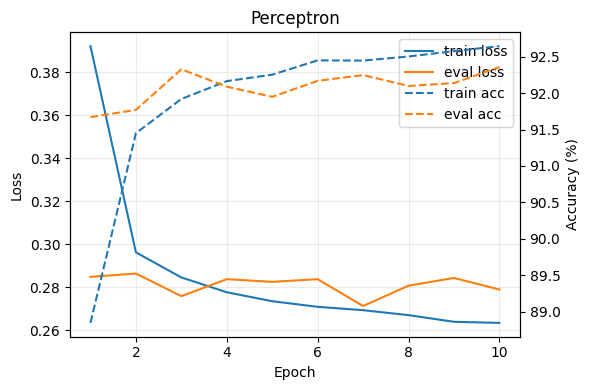

In [ ]:
# Perceptron
model1 = run(Perceptron(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="Perceptron")
plot_history(model1["history"], title=model1["name"])

Epoch 01 | train 0.2456/92.74% | eval 0.1319/96.20%
Epoch 02 | train 0.1131/96.67% | eval 0.0994/96.99%
Epoch 03 | train 0.0826/97.53% | eval 0.0941/97.02%
Epoch 04 | train 0.0662/98.04% | eval 0.0891/97.18%
Epoch 05 | train 0.0562/98.31% | eval 0.0811/97.48%
Epoch 06 | train 0.0495/98.49% | eval 0.0816/97.39%
Epoch 07 | train 0.0460/98.65% | eval 0.0826/97.34%
Epoch 08 | train 0.0412/98.79% | eval 0.0994/96.92%
Epoch 09 | train 0.0429/98.67% | eval 0.0805/97.58%
Epoch 10 | train 0.0399/98.77% | eval 0.0796/97.45%
El mejor resultado: acc=97.58%


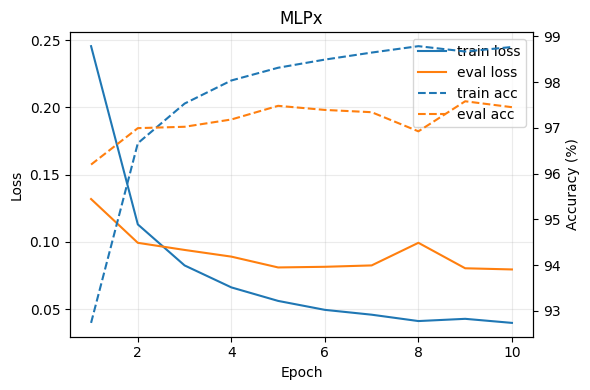

In [ ]:
# MLPx
model2 = run(MLPx(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="MLPx")
plot_history(model2["history"], title=model2["name"])

Epoch 01 | train 0.2491/92.75% | eval 0.1322/96.04%
Epoch 02 | train 0.1105/96.56% | eval 0.1011/96.72%
Epoch 03 | train 0.0826/97.44% | eval 0.0941/97.27%
Epoch 04 | train 0.0730/97.66% | eval 0.0898/97.14%
Epoch 05 | train 0.0624/98.03% | eval 0.0887/97.34%
Epoch 06 | train 0.0579/98.11% | eval 0.0842/97.40%
Epoch 07 | train 0.0514/98.35% | eval 0.1141/96.21%
Epoch 08 | train 0.0518/98.23% | eval 0.0914/97.19%
Epoch 09 | train 0.0464/98.47% | eval 0.0835/97.40%
Epoch 10 | train 0.0485/98.39% | eval 0.0893/97.21%
El mejor resultado: acc=97.40%


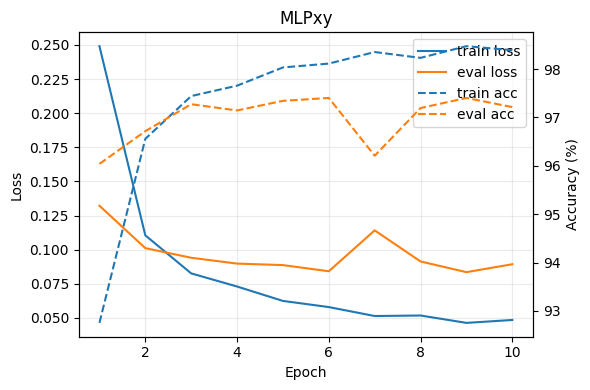

In [ ]:
# MLPxy
model3 = run(MLPxy(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="MLPxy")
plot_history(model3["history"], title=model3["name"])

Epoch 01 | train 0.3940/89.30% | eval 0.1887/94.61%
Epoch 02 | train 0.1602/95.33% | eval 0.1180/96.68%
Epoch 03 | train 0.1053/96.96% | eval 0.0857/97.51%
Epoch 04 | train 0.0798/97.77% | eval 0.0641/98.06%
Epoch 05 | train 0.0658/98.06% | eval 0.0546/98.37%
Epoch 06 | train 0.0578/98.31% | eval 0.0482/98.62%
Epoch 07 | train 0.0519/98.50% | eval 0.0451/98.74%
Epoch 08 | train 0.0476/98.60% | eval 0.0428/98.74%
Epoch 09 | train 0.0442/98.71% | eval 0.0402/98.81%
Epoch 10 | train 0.0419/98.77% | eval 0.0400/98.85%
El mejor resultado: acc=98.85%


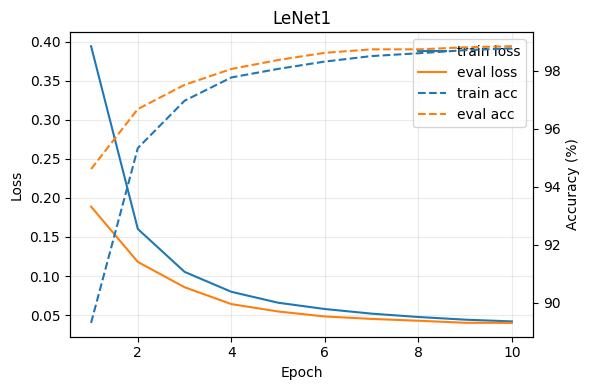

In [ ]:
# LeNet1
model4 = run(LeNet1(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet-1")
plot_history(model4["history"], title=model4["name"])

Epoch 01 | train 0.1492/95.70% | eval 0.0670/97.80%
Epoch 02 | train 0.0543/98.38% | eval 0.0446/98.53%
Epoch 03 | train 0.0437/98.64% | eval 0.0375/98.75%
Epoch 04 | train 0.0377/98.79% | eval 0.0404/98.63%
Epoch 05 | train 0.0367/98.89% | eval 0.0398/98.74%
Epoch 06 | train 0.0336/98.93% | eval 0.0425/98.71%
Epoch 07 | train 0.0325/98.96% | eval 0.0383/98.79%
Epoch 08 | train 0.0308/99.05% | eval 0.0411/98.61%
Epoch 09 | train 0.0317/98.99% | eval 0.0435/98.58%
Epoch 10 | train 0.0285/99.05% | eval 0.0361/98.87%
El mejor resultado: acc=98.87%


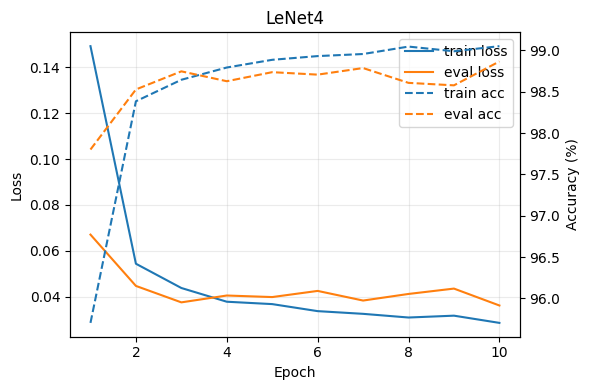

In [ ]:
# LeNet4
model5 = run(LeNet4(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet-4")
plot_history(model5["history"], title=model5["name"])

Epoch 01 | train 0.1829/95.15% | eval 0.0643/97.95%
Epoch 02 | train 0.0642/97.99% | eval 0.0482/98.51%
Epoch 03 | train 0.0505/98.43% | eval 0.0438/98.63%
Epoch 04 | train 0.0486/98.47% | eval 0.0504/98.47%
Epoch 05 | train 0.0422/98.73% | eval 0.0406/98.74%
Epoch 06 | train 0.0408/98.71% | eval 0.0494/98.47%
Epoch 07 | train 0.0376/98.81% | eval 0.0458/98.49%
Epoch 08 | train 0.0375/98.84% | eval 0.0353/98.91%
Epoch 09 | train 0.0346/98.86% | eval 0.0371/98.83%
Epoch 10 | train 0.0345/98.92% | eval 0.0453/98.63%
El mejor resultado: acc=98.91%


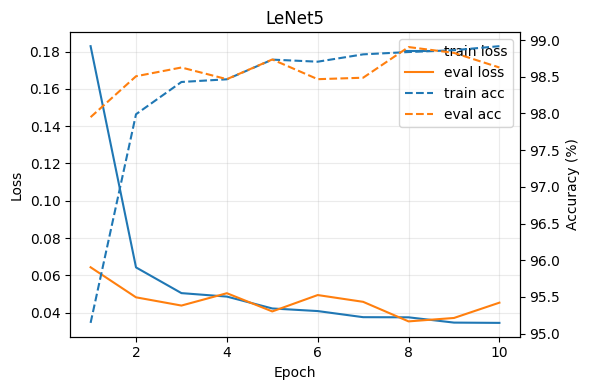

In [ ]:
# LeNet5
model6 = run(LeNet5(), trainLoader, evalLoader, n_epoch=10, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet-5")
plot_history(model6["history"], title=model6["name"])

# Fashion MNIST

In [ ]:
# Parametros
n_batch   = 64
n_workers = 2
n_epoch   = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
tfm = transforms.Compose([
    transforms.Pad(2), # Extendemos 28x28 -> 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

In [ ]:
trainData = datasets.FashionMNIST(root="./fashion", train=True,  download=True, transform=tfm)
evalData  = datasets.FashionMNIST(root="./fashion", train=False, download=True, transform=tfm)

trainLoader = DataLoader(trainData, batch_size=n_batch, shuffle=True,
                          num_workers=n_workers, pin_memory=True)
evalLoader  = DataLoader(evalData, batch_size=n_batch, shuffle=False,
                          num_workers=n_workers, pin_memory=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.9MB/s]


Epoch 01 | train 0.5345/81.28% | eval 0.4998/82.63%
Epoch 02 | train 0.4499/84.35% | eval 0.4873/82.81%
Epoch 03 | train 0.4311/84.84% | eval 0.4906/82.27%
Epoch 04 | train 0.4261/85.00% | eval 0.5229/80.96%
Epoch 05 | train 0.4212/85.20% | eval 0.4845/83.04%
Epoch 06 | train 0.4136/85.55% | eval 0.4446/84.62%
Epoch 07 | train 0.4140/85.57% | eval 0.4520/84.15%
Epoch 08 | train 0.4059/85.74% | eval 0.4579/83.93%
Epoch 09 | train 0.4041/85.84% | eval 0.4923/82.15%
Epoch 10 | train 0.4057/85.91% | eval 0.4685/83.84%
Epoch 11 | train 0.4025/85.87% | eval 0.4601/83.78%
Epoch 12 | train 0.4003/85.99% | eval 0.4628/83.47%
Epoch 13 | train 0.3992/85.94% | eval 0.4956/82.13%
Epoch 14 | train 0.4005/85.78% | eval 0.4664/83.49%
Epoch 15 | train 0.3959/86.11% | eval 0.4540/84.22%
Epoch 16 | train 0.3930/86.11% | eval 0.4708/83.53%
Epoch 17 | train 0.3954/86.10% | eval 0.4639/84.13%
Epoch 18 | train 0.3958/86.04% | eval 0.4836/82.92%
Epoch 19 | train 0.3919/86.25% | eval 0.4654/84.17%
Epoch 20 | t

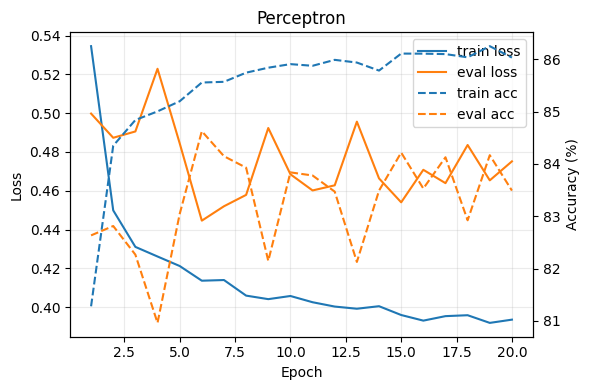

In [ ]:
# Perceptron
model1 = run(Perceptron(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="Perceptron")
plot_history(model1["history"], title=model1["name"])

Epoch 01 | train 0.4644/83.31% | eval 0.4276/84.22%
Epoch 02 | train 0.3779/86.20% | eval 0.4019/85.58%
Epoch 03 | train 0.3580/86.90% | eval 0.3874/86.33%
Epoch 04 | train 0.3415/87.57% | eval 0.3884/86.48%
Epoch 05 | train 0.3342/87.73% | eval 0.3764/86.01%
Epoch 06 | train 0.3257/87.94% | eval 0.3934/86.01%
Epoch 07 | train 0.3171/88.31% | eval 0.3818/86.64%
Epoch 08 | train 0.3155/88.35% | eval 0.3969/85.59%
Epoch 09 | train 0.3083/88.68% | eval 0.3815/86.10%
Epoch 10 | train 0.3041/88.73% | eval 0.3698/86.35%
Epoch 11 | train 0.2966/89.00% | eval 0.3786/86.40%
Epoch 12 | train 0.2945/89.23% | eval 0.3662/86.58%
Epoch 13 | train 0.2896/89.31% | eval 0.3715/86.82%
Epoch 14 | train 0.2910/89.24% | eval 0.3662/86.86%
Epoch 15 | train 0.2815/89.70% | eval 0.3662/86.95%
Epoch 16 | train 0.2829/89.56% | eval 0.3767/86.82%
Epoch 17 | train 0.2761/89.73% | eval 0.3619/87.46%
Epoch 18 | train 0.2720/89.90% | eval 0.3800/86.55%
Epoch 19 | train 0.2727/89.79% | eval 0.3854/86.31%
Epoch 20 | t

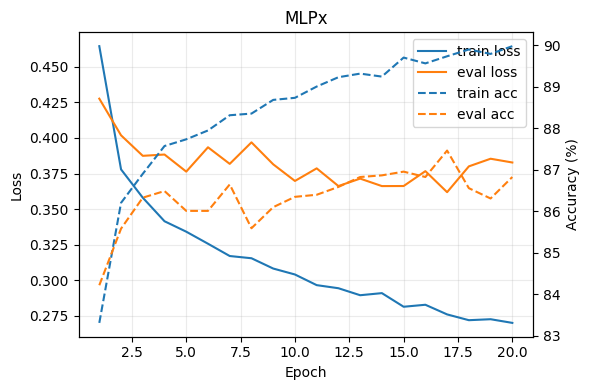

In [ ]:
# MLPx
model2 = run(MLPx(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="MLPx")
plot_history(model2["history"], title=model2["name"])

Epoch 01 | train 0.4851/82.75% | eval 0.4198/84.85%
Epoch 02 | train 0.3864/85.92% | eval 0.4045/85.60%
Epoch 03 | train 0.3623/86.67% | eval 0.3932/85.92%
Epoch 04 | train 0.3474/87.29% | eval 0.3804/86.12%
Epoch 05 | train 0.3356/87.64% | eval 0.3720/86.48%
Epoch 06 | train 0.3292/87.90% | eval 0.3787/86.42%
Epoch 07 | train 0.3246/87.91% | eval 0.3722/86.67%
Epoch 08 | train 0.3221/88.09% | eval 0.3619/86.81%
Epoch 09 | train 0.3092/88.56% | eval 0.3604/86.98%
Epoch 10 | train 0.3034/88.81% | eval 0.3619/87.13%
Epoch 11 | train 0.3036/88.71% | eval 0.3637/86.96%
Epoch 12 | train 0.2983/88.93% | eval 0.3616/87.06%
Epoch 13 | train 0.2949/89.13% | eval 0.3881/86.30%
Epoch 14 | train 0.2928/89.24% | eval 0.3624/87.03%
Epoch 15 | train 0.2856/89.43% | eval 0.3555/87.05%
Epoch 16 | train 0.2809/89.52% | eval 0.3552/87.50%
Epoch 17 | train 0.2786/89.60% | eval 0.3625/87.03%
Epoch 18 | train 0.2754/89.81% | eval 0.3641/87.24%
Epoch 19 | train 0.2758/89.65% | eval 0.3602/87.26%
Epoch 20 | t

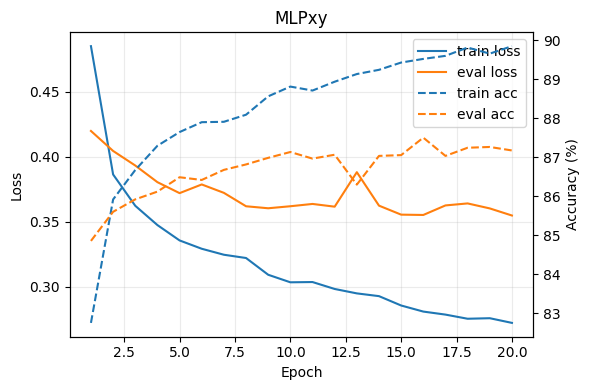

In [ ]:
# MLPxy
model3 = run(MLPxy(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="MLPxy")
plot_history(model3["history"], title=model3["name"])

Epoch 01 | train 0.6635/76.51% | eval 0.5062/81.85%
Epoch 02 | train 0.4490/83.97% | eval 0.4488/83.91%
Epoch 03 | train 0.4054/85.48% | eval 0.4221/85.02%
Epoch 04 | train 0.3790/86.56% | eval 0.3891/85.93%
Epoch 05 | train 0.3620/87.10% | eval 0.3828/86.26%
Epoch 06 | train 0.3480/87.52% | eval 0.3843/86.21%
Epoch 07 | train 0.3366/87.88% | eval 0.3540/87.38%
Epoch 08 | train 0.3281/88.17% | eval 0.3431/87.63%
Epoch 09 | train 0.3201/88.53% | eval 0.3418/87.73%
Epoch 10 | train 0.3136/88.77% | eval 0.3370/87.78%
Epoch 11 | train 0.3083/88.97% | eval 0.3396/87.73%
Epoch 12 | train 0.3037/89.12% | eval 0.3313/87.98%
Epoch 13 | train 0.2994/89.22% | eval 0.3278/88.19%
Epoch 14 | train 0.2952/89.36% | eval 0.3218/88.41%
Epoch 15 | train 0.2923/89.48% | eval 0.3230/88.15%
Epoch 16 | train 0.2887/89.52% | eval 0.3113/88.64%
Epoch 17 | train 0.2862/89.61% | eval 0.3111/88.60%
Epoch 18 | train 0.2826/89.72% | eval 0.3178/88.45%
Epoch 19 | train 0.2815/89.85% | eval 0.3056/89.04%
Epoch 20 | t

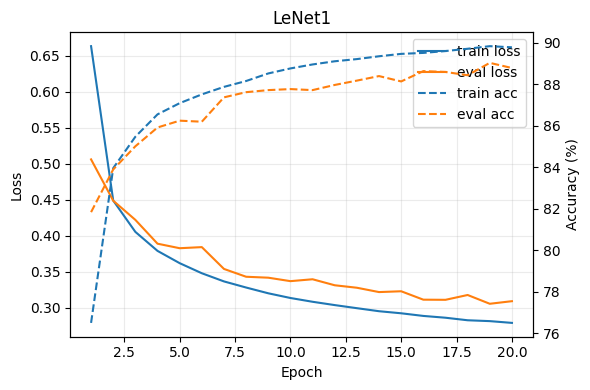

In [ ]:
# LeNet1
model4 = run(LeNet1(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet1")
plot_history(model4["history"], title=model4["name"])

Epoch 01 | train 0.4599/83.44% | eval 0.3857/85.96%
Epoch 02 | train 0.3317/87.99% | eval 0.3359/87.88%
Epoch 03 | train 0.2992/89.07% | eval 0.3099/88.73%
Epoch 04 | train 0.2728/90.12% | eval 0.3021/89.20%
Epoch 05 | train 0.2559/90.51% | eval 0.3096/88.57%
Epoch 06 | train 0.2417/91.14% | eval 0.2879/89.70%
Epoch 07 | train 0.2278/91.68% | eval 0.3066/89.27%
Epoch 08 | train 0.2208/91.99% | eval 0.2774/90.08%
Epoch 09 | train 0.2090/92.28% | eval 0.2726/90.51%
Epoch 10 | train 0.1994/92.56% | eval 0.2790/90.13%
Epoch 11 | train 0.1927/93.00% | eval 0.2910/89.65%
Epoch 12 | train 0.1854/93.13% | eval 0.2798/90.07%
Epoch 13 | train 0.1771/93.45% | eval 0.2840/89.93%
Epoch 14 | train 0.1709/93.67% | eval 0.2902/90.11%
Epoch 15 | train 0.1640/93.98% | eval 0.2860/89.82%
Epoch 16 | train 0.1550/94.26% | eval 0.3014/89.83%
Epoch 17 | train 0.1503/94.44% | eval 0.2787/90.53%
Epoch 18 | train 0.1446/94.67% | eval 0.2898/90.27%
Epoch 19 | train 0.1398/94.86% | eval 0.2785/90.38%
Epoch 20 | t

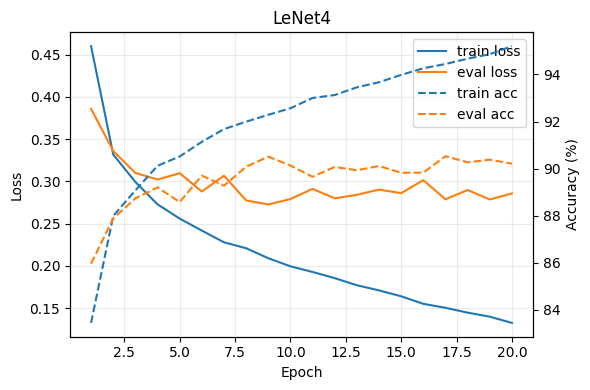

In [ ]:
# LeNet4
model5 = run(LeNet4(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet4")
plot_history(model5["history"], title=model5["name"])

Epoch 01 | train 0.5084/81.94% | eval 0.3909/86.02%
Epoch 02 | train 0.3545/87.07% | eval 0.3529/87.42%
Epoch 03 | train 0.3188/88.46% | eval 0.3345/88.09%
Epoch 04 | train 0.2922/89.29% | eval 0.3421/87.45%
Epoch 05 | train 0.2740/89.92% | eval 0.3735/86.07%
Epoch 06 | train 0.2611/90.53% | eval 0.3137/88.39%
Epoch 07 | train 0.2500/90.97% | eval 0.3058/89.05%
Epoch 08 | train 0.2383/91.16% | eval 0.3028/88.93%
Epoch 09 | train 0.2318/91.48% | eval 0.2998/89.23%
Epoch 10 | train 0.2212/91.87% | eval 0.3022/89.21%
Epoch 11 | train 0.2127/92.14% | eval 0.2952/89.63%
Epoch 12 | train 0.2058/92.46% | eval 0.2875/89.86%
Epoch 13 | train 0.1987/92.78% | eval 0.2996/89.54%
Epoch 14 | train 0.1907/92.95% | eval 0.2973/90.19%
Epoch 15 | train 0.1855/93.15% | eval 0.2968/89.51%
Epoch 16 | train 0.1766/93.49% | eval 0.3089/89.31%
Epoch 17 | train 0.1762/93.50% | eval 0.2845/90.18%
Epoch 18 | train 0.1705/93.67% | eval 0.3068/89.61%
Epoch 19 | train 0.1622/94.00% | eval 0.3017/89.59%
Epoch 20 | t

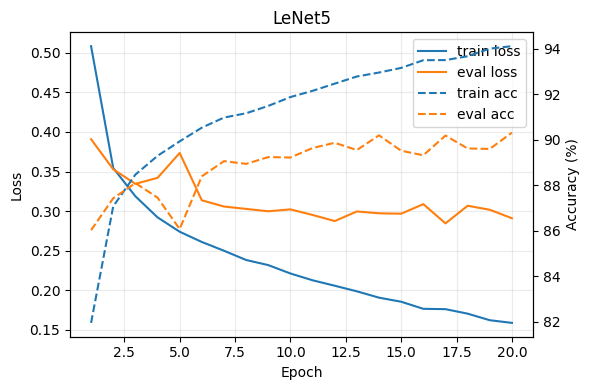

In [ ]:
# LeNet5
model6 = run(LeNet5(), trainLoader, evalLoader, n_epoch=n_epoch, lr=1e-3, λ=1e-4,
             path="checkpoint", model_name="LeNet5")
plot_history(model6["history"], title=model6["name"])

# Visualizar features

In [ ]:
import numpy as np
from sklearn.manifold import TSNE

In [ ]:
@torch.no_grad()
def featuresMLPxy(model, loader, device):
    model.eval()
    features = model[:-1]
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        z = features(x).cpu()   # [n_batch, 100]
        feats .append(z)
        labels.append(y)
    feats  = torch.cat(feats,  0).numpy()
    labels = torch.cat(labels, 0).numpy()

    return labels, feats

In [ ]:
@torch.no_grad()
def featuresLeNet5(model, loader, device):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        z = model.encoder(x)            # [n_batch, n_chan, 1, 1]
        z = z.view(z.size(0), -1).cpu() # [n_batch, n_chan]
        feats .append(z)
        labels.append(y)
    feats  = torch.cat(feats,  0).numpy()
    labels = torch.cat(labels, 0).numpy()

    return labels, feats

In [ ]:
def tsne2D(features, perplexity=30, iter=1000, seed=42):
    n = features.shape[0]
    px = min(perplexity, max(5, n//3))
    tsne = TSNE(n_components=2, perplexity=px, init="pca",
                learning_rate="auto", max_iter=1000, random_state=seed)
    return tsne.fit_transform(features.astype(np.float32))

In [ ]:
FASHION_CLASSES = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

def plot_tsne(Xa, ya, Xb, yb, titleA="LeNet-5", titleB="MLPxy"):
    fig, axs = plt.subplots(1, 2, figsize=(11,6))
    for c in range(10):
        selA = (ya == c)
        selB = (yb == c)
        axs[0].scatter(Xa[selA,0], Xa[selA,1], s=6, alpha=0.6, label=FASHION_CLASSES[c])
        axs[1].scatter(Xb[selB,0], Xb[selB,1], s=6, alpha=0.6, label=FASHION_CLASSES[c])
    axs[0].set_title(titleA); axs[1].set_title(titleB)
    for ax in axs:
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.grid(True, alpha=0.2)
    # leyenda única
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=8, markerscale=2)
    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()

In [ ]:
xMLP  , yMLP   = featuresMLPxy (model3["model"], evalLoader, device)
xLeNet, yLeNet = featuresLeNet5(model6["model"], evalLoader, device)

In [ ]:
tsneMLP   = tsne2D(yMLP,   perplexity=30, iter=1000)
tsneLeNet = tsne2D(yLeNet, perplexity=30, iter=1000)

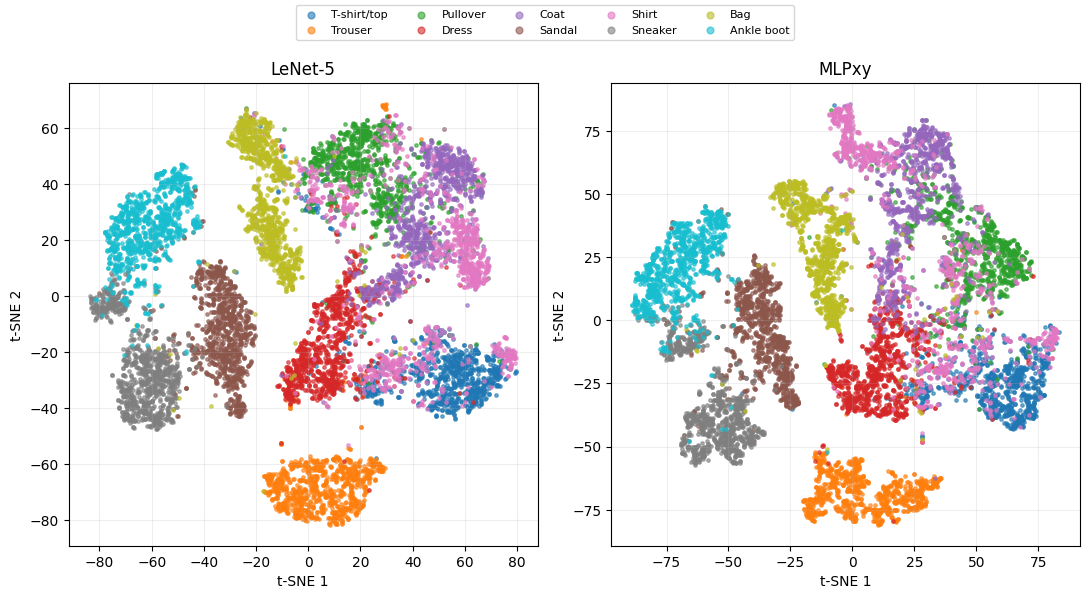

In [ ]:
plot_tsne(tsneLeNet, xLeNet, tsneMLP, xMLP)